In [9]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [10]:
#Loading the dataset
df = pd.read_csv("Cleaned_Global Store sales dataset.csv")

df.head()

,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [11]:
#Exploring the dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      51290 non-null  int64  
 1   Row ID          51290 non-null  int64  
 2   Order ID        51290 non-null  object 
 3   Order Date      51290 non-null  object 
 4   Ship Date       51290 non-null  object 
 5   Ship Mode       51290 non-null  object 
 6   Customer ID     51290 non-null  object 
 7   Customer Name   51290 non-null  object 
 8   Segment         51290 non-null  object 
 9   City            51290 non-null  object 
 10  State           51290 non-null  object 
 11  Country         51290 non-null  object 
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

,Unnamed: 0,Row ID,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25644.50000,25645.50000,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,14806.29199,487.565361,2.278766,0.212280,174.340972,57.296804
min,0.00000,1.00000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12822.25000,12823.25000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25644.50000,25645.50000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38466.75000,38467.75000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51289.00000,51290.00000,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [12]:
#Checking for missing values
df.isnull().sum()

Unnamed: 0        0
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64

In [13]:
#Calculating total sales
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

#Calculating total profit
total_profit = df['Profit'].sum()
print("Total Profit:", total_profit)

#Calculating average discount
avg_discount = df['Discount'].mean()
print("Average Discount:", avg_discount)

Total Sales: 12642501.909880001
Total Profit: 1467457.29128
Average Discount: 0.14290754533047378


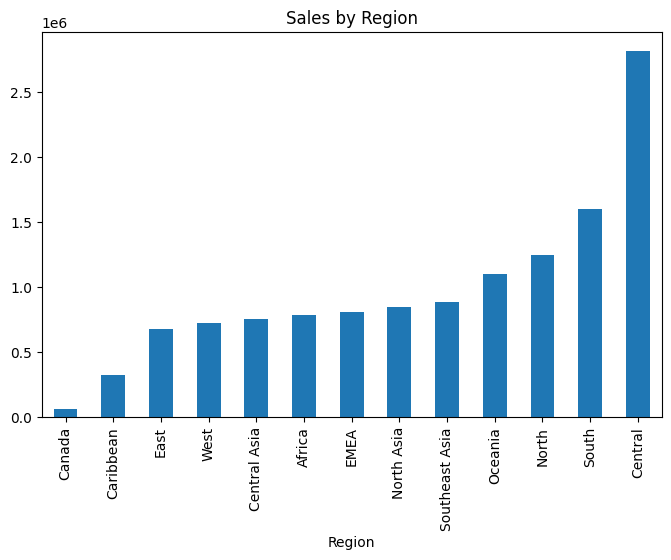

In [14]:
#Calculating sales by region
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

region_sales.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Region")
plt.show()

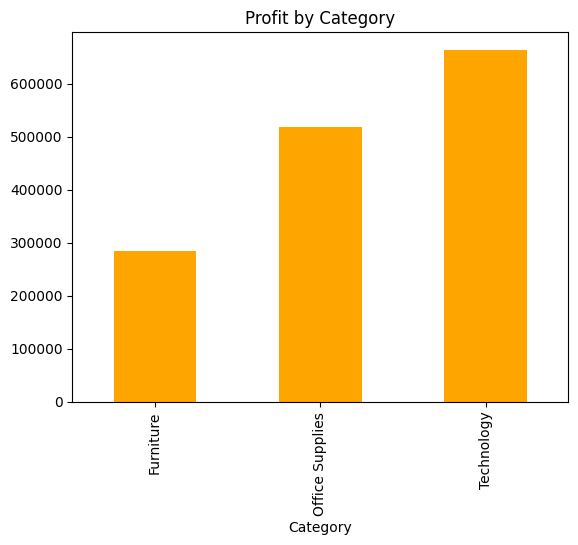

In [15]:
#calculating profit by category
category_profit = df.groupby('Category')['Profit'].sum()

category_profit.plot(kind='bar', color='orange')
plt.title("Profit by Category")
plt.show()

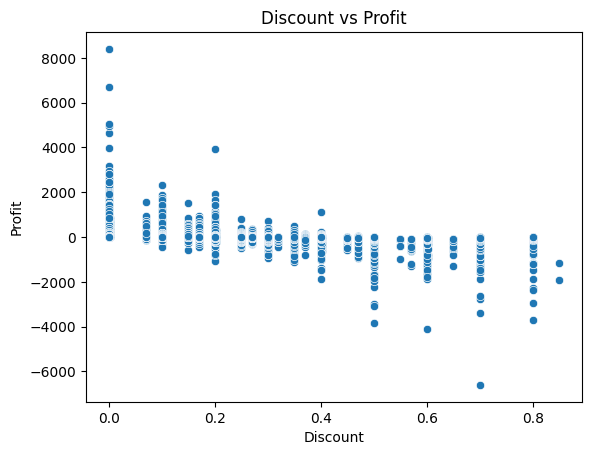

In [16]:
#discount vs profit analysis
sns.scatterplot(x=df['Discount'], y=df['Profit'])
plt.title("Discount vs Profit")
plt.show()

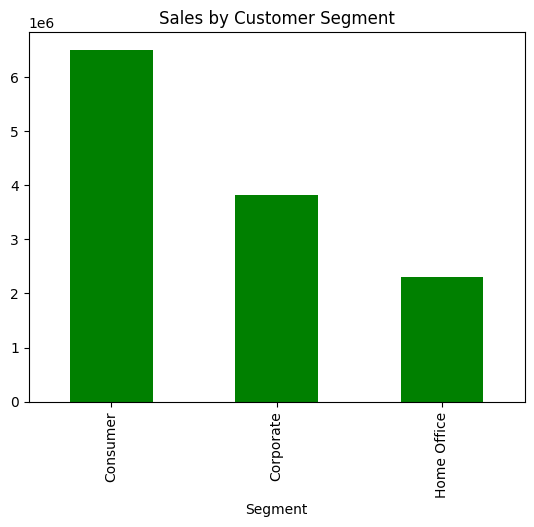

In [17]:
#Customer segment analysis
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(kind='bar', color='green')
plt.title("Sales by Customer Segment")
plt.show()

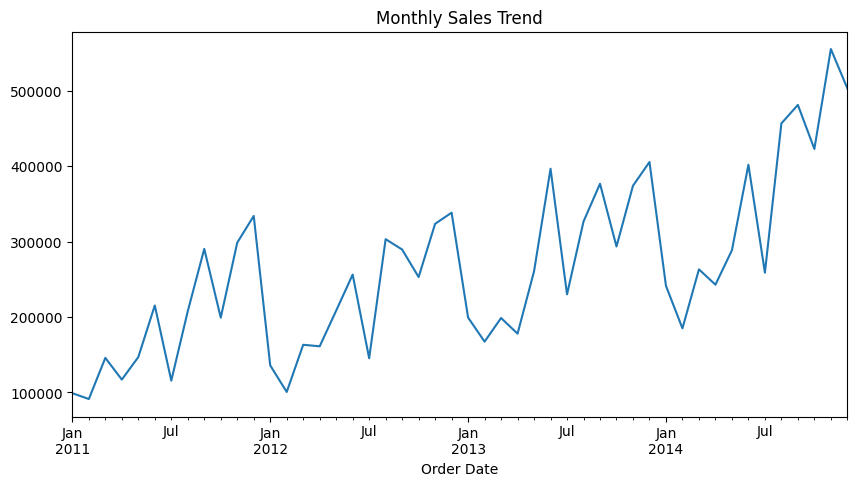

In [18]:
#Monthly sales trend
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.show()

Hypothesis Testing and Data Analysis

In [19]:
#Create two groups based on discount threshold
low_discount = df[df['Discount'] < 0.2]['Profit']
high_discount = df[df['Discount'] >= 0.2]['Profit']

In [20]:
#Performing t-test
t_stat, p_value = ttest_ind(low_discount, high_discount)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 65.91734457336543
P-value: 0.0
